In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("titanic.csv")

In [12]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
df.info()
print(df.describe())

print(df.loc[0,"Name"])
print(df.loc[0:4,["Name","Age","Sex"]])
print(df.iloc[0, 3])
print(df.iloc[0:5, 0:5])

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [14]:
male_over_50 = df[(df["Sex"] == "male") & (df["Age"] > 50)]

print("========== 1. MALE PASSENGERS OLDER THAN 50 ==========")
print("Number of male passengers older than 50:", len(male_over_50))

female_first_class = df[
    (df["Sex"] == "female") &
    (df["Pclass"] == 1)
]

female_first_class_count = len(female_first_class)

female_first_class_survival_rate = (
    female_first_class["Survived"].mean() * 100
)

print("\n========== 2. FEMALE FIRST-CLASS PASSENGERS ==========")
print("Number of female first-class passengers:",
      female_first_class_count)

print("Survival percentage:",
      female_first_class_survival_rate)
fare_median = df["Fare"].median()

condition_3 = df[
    (df["Age"] >= 20) &
    (df["Age"] <= 40) &
    (df["Fare"] > fare_median) &
    (df["Survived"] == 1)
]

print("\n========== 3. AGE 20-40, HIGH FARE AND SURVIVED ==========")
print("Overall Fare median:", fare_median)

print("Number of passengers:",
      len(condition_3))



condition_4 = df[
    (df["SibSp"] == 0) &
    (df["Parch"] == 0) &
    (df["Age"] < 30) &
    (df["Survived"] == 0)
]

print("\n========== 4. TRAVELLING ALONE, AGE < 30, DID NOT SURVIVE ==========")
print("Number of passengers:",
      len(condition_4))

southampton_data = df[df["Embarked"] == "S"]

southampton_median_fare = southampton_data["Fare"].median()

condition_5 = df[
    (df["Embarked"] == "S") &
    (df["Pclass"].isin([2, 3])) &
    (df["Fare"] > southampton_median_fare)
]

print("\n========== 5. EMBARKED S, PCLASS 2 OR 3, HIGH FARE ==========")

print("Southampton median Fare:",
      southampton_median_fare)

print("Number of passengers:",
      len(condition_5))

========== 1. MALE PASSENGERS OLDER THAN 50 ==========
Number of male passengers older than 50: 47

========== 2. FEMALE FIRST-CLASS PASSENGERS ==========
Number of female first-class passengers: 94
Survival percentage: 96.80851063829788

========== 3. AGE 20-40, HIGH FARE AND SURVIVED ==========
Overall Fare median: 14.4542
Number of passengers: 104

========== 4. TRAVELLING ALONE, AGE < 30, DID NOT SURVIVE ==========
Number of passengers: 141

========== 5. EMBARKED S, PCLASS 2 OR 3, HIGH FARE ==========
Southampton median Fare: 13.0
Number of passengers: 193


In [15]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

print("========== 1. SURVIVAL RATE BY SEX ==========")
print(survival_by_sex)

survival_by_pclass = df.groupby("Pclass")["Survived"].mean() * 100

print("\n========== 2. SURVIVAL RATE BY PCLASS ==========")
print(survival_by_pclass)

average_age_fare = df.groupby("Pclass")[["Age", "Fare"]].mean()

print("\n========== 3. AVERAGE AGE AND FARE BY PCLASS ==========")
print(average_age_fare)

sex_pclass = df.groupby(["Sex", "Pclass"]).agg(
    Passenger_Count=("PassengerId", "count"),
    Survival_Rate=("Survived", "mean")
)

sex_pclass["Survival_Rate"] = sex_pclass["Survival_Rate"] * 100

print("\n========== 4. PASSENGER COUNT AND SURVIVAL RATE BY SEX-PCLASS ==========")
print(sex_pclass)
embarked_summary = df.groupby("Embarked").agg(
    Passenger_Count=("PassengerId", "count"),
    Average_Fare=("Fare", "mean"),
    Survival_Rate=("Survived", "mean")
)

embarked_summary["Survival_Rate"] = (
    embarked_summary["Survival_Rate"] * 100
)

print("\n========== 5. PASSENGER COUNT, AVERAGE FARE AND SURVIVAL RATE BY EMBARKED ==========")
print(embarked_summary)

========== 1. SURVIVAL RATE BY SEX ==========
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

========== 2. SURVIVAL RATE BY PCLASS ==========
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

========== 3. AVERAGE AGE AND FARE BY PCLASS ==========
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550

========== 4. PASSENGER COUNT AND SURVIVAL RATE BY SEX-PCLASS ==========
               Passenger_Count  Survival_Rate
Sex    Pclass                                
female 1                    94      96.808511
       2                    76      92.105263
       3                   144      50.000000
male   1                   122      36.885246
       2                   108      15.740741
       3                   347      13.544669

========== 5. PASSENGER COUNT, AVERAGE FARE AND SURVIVAL RATE BY EMBARKED ==========
          Passen

========== 1. SURVIVAL RATE BY SEX ==========
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

========== 2. SURVIVAL RATE BY PCLASS ==========
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

========== 3. AVERAGE AGE AND FARE BY PCLASS ==========
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550

========== 4. PASSENGER COUNT AND SURVIVAL RATE BY SEX-PCLASS ==========
               Passenger_Count  Survival_Rate
Sex    Pclass                                
female 1                    94      96.808511
       2                    76      92.105263
       3                   144      50.000000
male   1                   122      36.885246
       2                   108      15.740741
       3                   347      13.544669

========== 5. PASSENGER COUNT, AVERAGE FARE AND SURVIVAL RATE BY EMBARKED ==========
          Passen

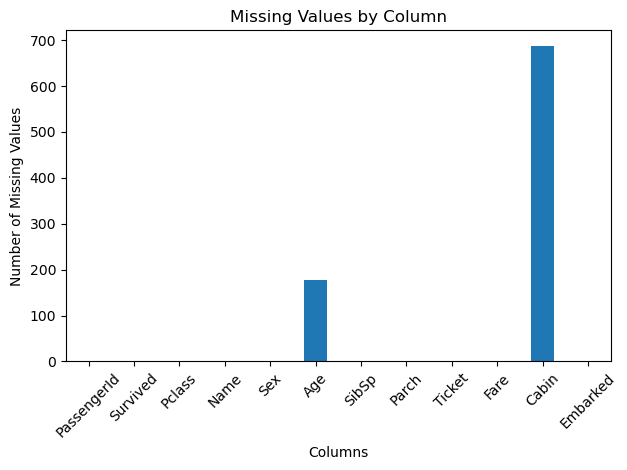


========== 3. AGE MISSING VALUES ==========
Missing Age values BEFORE filling: 177
Mean Age: 29.69911764705882
Missing Age values AFTER filling: 0

========== 4. AGE IMPUTATION METHODS ==========
Original missing Age values: 177

Mean Imputation
Missing Age values: 0

Median Imputation
Missing Age values: 0

Mode Imputation
Age Mode: 24.0
Missing Age values: 0

Random Value Imputation
Missing Age values: 0

========== 5. FARE OUTLIERS ==========
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Fare Outliers: 116


In [17]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

print("========== 1. SURVIVAL RATE BY SEX ==========")
print(survival_by_sex)

survival_by_pclass = df.groupby("Pclass")["Survived"].mean() * 100

print("\n========== 2. SURVIVAL RATE BY PCLASS ==========")
print(survival_by_pclass)
average_age_fare = df.groupby("Pclass")[["Age", "Fare"]].mean()

print("\n========== 3. AVERAGE AGE AND FARE BY PCLASS ==========")
print(average_age_fare)

sex_pclass = df.groupby(["Sex", "Pclass"]).agg(
    Passenger_Count=("PassengerId", "count"),
    Survival_Rate=("Survived", "mean")
)
sex_pclass["Survival_Rate"] = sex_pclass["Survival_Rate"] * 100

print("\n========== 4. PASSENGER COUNT AND SURVIVAL RATE BY SEX-PCLASS ==========")
print(sex_pclass)

embarked_summary = df.groupby("Embarked").agg(
    Passenger_Count=("PassengerId", "count"),
    Average_Fare=("Fare", "mean"),
    Survival_Rate=("Survived", "mean")
)
embarked_summary["Survival_Rate"] = (
    embarked_summary["Survival_Rate"] * 100
)

print("\n========== 5. PASSENGER COUNT, AVERAGE FARE AND SURVIVAL RATE BY EMBARKED ==========")
print(embarked_summary)
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("========== 1. MISSING VALUES ==========")
print(missing_summary)


missing_count.plot(kind="bar")

plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values by Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n========== 3. AGE MISSING VALUES ==========")

print("Missing Age values BEFORE filling:",
      df["Age"].isnull().sum())

age_mean = df["Age"].mean()

print("Mean Age:", age_mean)

df_age_mean = df.copy()

df_age_mean["Age"] = df_age_mean["Age"].fillna(age_mean)

print("Missing Age values AFTER filling:",
      df_age_mean["Age"].isnull().sum())

print("\n========== 4. AGE IMPUTATION METHODS ==========")

print("Original missing Age values:",
      df["Age"].isnull().sum())

df_mean = df.copy()

df_mean["Age"] = df_mean["Age"].fillna(
    df_mean["Age"].mean()
)

print("\nMean Imputation")
print("Missing Age values:",
      df_mean["Age"].isnull().sum())

df_median = df.copy()

df_median["Age"] = df_median["Age"].fillna(
    df_median["Age"].median()
)

print("\nMedian Imputation")
print("Missing Age values:",
      df_median["Age"].isnull().sum())

df_mode = df.copy()

age_mode = df_mode["Age"].mode()[0]

df_mode["Age"] = df_mode["Age"].fillna(age_mode)

print("\nMode Imputation")
print("Age Mode:", age_mode)
print("Missing Age values:",
      df_mode["Age"].isnull().sum())

df_random = df.copy()

np.random.seed(42)

missing_age_count = df_random["Age"].isnull().sum()

random_values = np.random.choice(
    df_random["Age"].dropna(),
    size=missing_age_count,
    replace=True
)

df_random.loc[
    df_random["Age"].isnull(),
    "Age"
] = random_values

print("\nRandom Value Imputation")
print("Missing Age values:",
      df_random["Age"].isnull().sum())

print("\n========== 5. FARE OUTLIERS ==========")

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Fare Outliers:",
      len(fare_outliers))

             Missing Count  Missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467


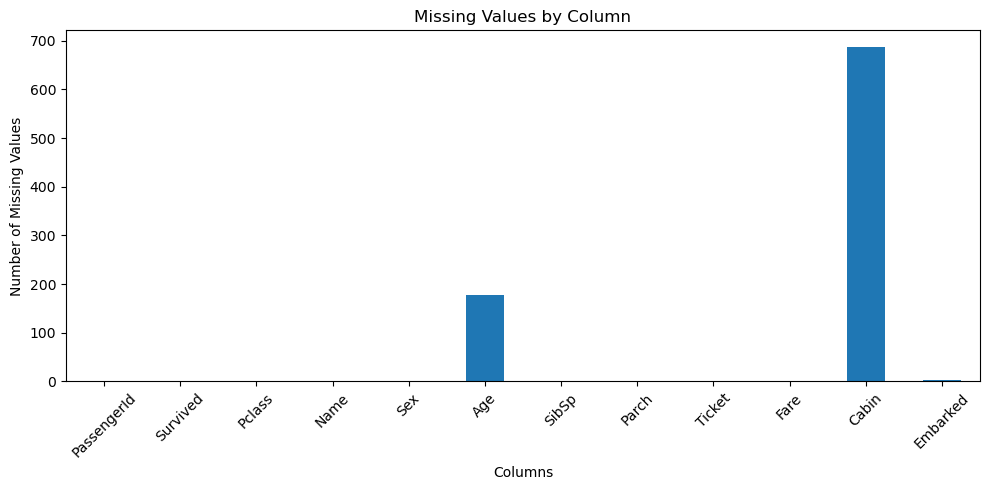


Age Missing Values Before:
177
Mean Age: 29.69911764705882
Age Missing Values After:
0

Mean Imputation Missing Values: 0
Median Imputation Missing Values: 0
Mode Imputation Missing Values: 0
Random Imputation Missing Values: 0

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Fare Outliers: 116

Fare Outliers:
     PassengerId                                               Name      Fare
1              2  Cumings, Mrs. John Bradley (Florence Briggs Th...   71.2833
27            28                     Fortune, Mr. Charles Alexander  263.0000
31            32     Spencer, Mrs. William Augustus (Marie Eugenie)  146.5208
34            35                            Meyer, Mr. Edgar Joseph   82.1708
52            53           Harper, Mrs. Henry Sleeper (Myna Haxtun)   76.7292
..           ...                                                ...       ...
846          847                           Sage, Mr. Douglas Bullen   69.5500
849          850       Gol

In [18]:

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_summary)

plt.figure(figsize=(10, 5))
missing_count.plot(kind="bar")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values by Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nAge Missing Values Before:")
print(df["Age"].isnull().sum())

age_mean = df["Age"].mean()

df_age_mean = df.copy()
df_age_mean["Age"] = df_age_mean["Age"].fillna(age_mean)

print("Mean Age:", age_mean)
print("Age Missing Values After:")
print(df_age_mean["Age"].isnull().sum())

df_mean = df.copy()
df_mean["Age"] = df_mean["Age"].fillna(df_mean["Age"].mean())
print("\nMean Imputation Missing Values:", df_mean["Age"].isnull().sum())

df_median = df.copy()
df_median["Age"] = df_median["Age"].fillna(df_median["Age"].median())
print("Median Imputation Missing Values:", df_median["Age"].isnull().sum())

df_mode = df.copy()
age_mode = df_mode["Age"].mode()[0]
df_mode["Age"] = df_mode["Age"].fillna(age_mode)
print("Mode Imputation Missing Values:", df_mode["Age"].isnull().sum())

df_random = df.copy()
np.random.seed(42)

missing_age_count = df_random["Age"].isnull().sum()

random_values = np.random.choice(
    df_random["Age"].dropna(),
    size=missing_age_count,
    replace=True
)

df_random.loc[df_random["Age"].isnull(), "Age"] = random_values

print("Random Imputation Missing Values:", df_random["Age"].isnull().sum())

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Fare Outliers:", len(fare_outliers))

print("\nFare Outliers:")
print(fare_outliers[["PassengerId", "Name", "Fare"]])

In [19]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("FamilySize and IsAlone:")
print(df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10))

pivot_table = pd.pivot_table(
    df,
    index="Sex",
    columns="Pclass",
    values="Survived",
    aggfunc="mean"
)

print("\nPivot Table:")
print(pivot_table)

highest_group = pivot_table.stack().idxmax()
highest_rate = pivot_table.stack().max()

lowest_group = pivot_table.stack().idxmin()
lowest_rate = pivot_table.stack().min()

print("\nHighest Survival Group:")
print("Sex:", highest_group[0])
print("Pclass:", highest_group[1])
print("Survival Rate:", highest_rate * 100, "%")

print("\nLowest Survival Group:")
print("Sex:", lowest_group[0])
print("Pclass:", lowest_group[1])
print("Survival Rate:", lowest_rate * 100, "%")

FamilySize and IsAlone:
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0

Pivot Table:
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447

Highest Survival Group:
Sex: female
Pclass: 1
Survival Rate: 96.80851063829788 %

Lowest Survival Group:
Sex: male
Pclass: 3
Survival Rate: 13.544668587896252 %


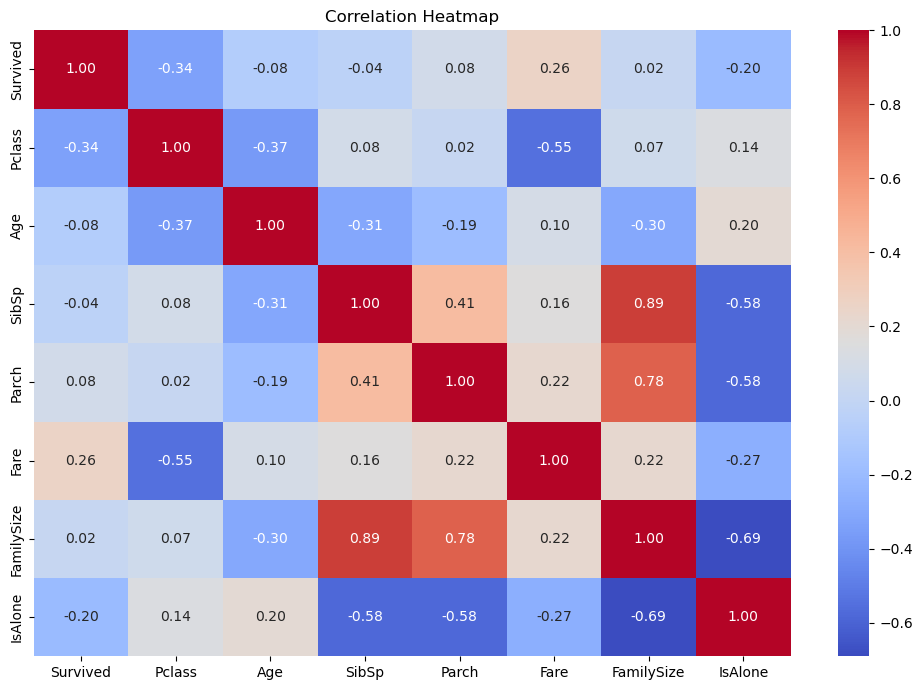

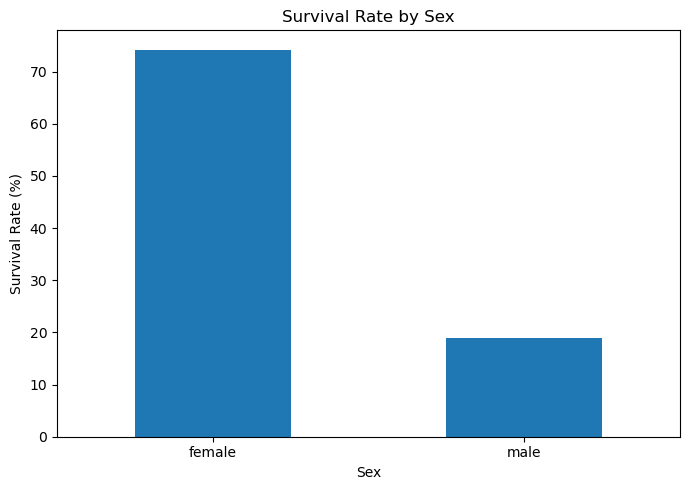

Survival Rate by Sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


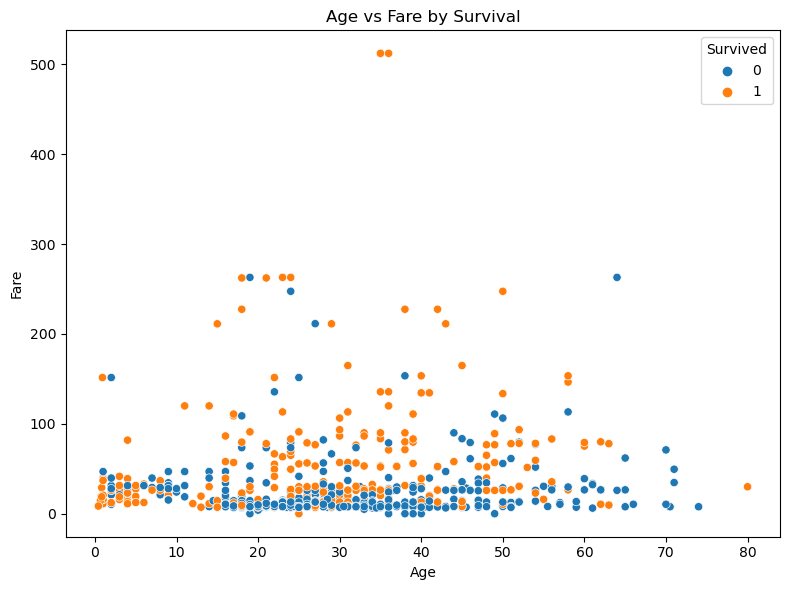


Male Survival Rate: 18.890814558058924 %
Female Survival Rate: 74.20382165605095 %

Observations:
1. Female passengers generally had a higher survival rate than male passengers.
2. First-class passengers generally had a higher survival rate than third-class passengers.
3. Passenger class and fare show a negative relationship because higher-class passengers generally paid higher fares.
4. Age and Fare do not show a strong linear relationship.
5. Fare contains several high-value observations that can be identified as outliers.
6. Survival is related to Sex and Pclass, with noticeable differences between groups.
7. Passengers travelling alone can have different survival outcomes compared with passengers travelling with family.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

correlation = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(7, 5))
survival_by_sex.plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Survival Rate by Sex:")
print(survival_by_sex)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Survival")
plt.tight_layout()
plt.show()

male_survival = df[df["Sex"] == "male"]["Survived"].mean() * 100
female_survival = df[df["Sex"] == "female"]["Survived"].mean() * 100

print("\nMale Survival Rate:", male_survival, "%")
print("Female Survival Rate:", female_survival, "%")

print("\nObservations:")
print("1. Female passengers generally had a higher survival rate than male passengers.")
print("2. First-class passengers generally had a higher survival rate than third-class passengers.")
print("3. Passenger class and fare show a negative relationship because higher-class passengers generally paid higher fares.")
print("4. Age and Fare do not show a strong linear relationship.")
print("5. Fare contains several high-value observations that can be identified as outliers.")
print("6. Survival is related to Sex and Pclass, with noticeable differences between groups.")
print("7. Passengers travelling alone can have different survival outcomes compared with passengers travelling with family.")